# 02 — EMRI Trajectory Integration

This notebook covers `fewtrax.trajectory.inspiral` — the adiabatic EMRI inspiral ODE.

**Topics:**
- The adiabatic inspiral ODE and the $\mu/M$ mass-ratio scaling
- Converting radiation-reaction forces $(\dot{E}, \dot{L})$ to $(\dot{p}, \dot{e})$ via the geodesic Jacobian
- diffrax `Tsit5` adaptive solver with separatrix event termination
- JIT compilation and `@eqx.filter_jit`
- Visualising $p(t)$, $e(t)$, and the orbital phases $\Phi_\phi(t)$

---

## Background: The Adiabatic Approximation

In the **adiabatic approximation** the mass ratio $\eta = \mu/M \ll 1$ allows a separation of timescales:
- *Fast*: orbital motion (Boyer–Lindquist period $T_{\rm orb} \sim M$)
- *Slow*: radiation-reaction (inspiral timescale $T_{\rm insp} \sim M/\eta \sim 10^5\,{\rm yr}$ for a typical EMRI)

On the slow timescale, the orbital parameters $(p, e)$ evolve according to

$$
\frac{dp}{dt} = \dot{p}(a, p, e), \qquad \frac{de}{dt} = \dot{e}(a, p, e)
$$

driven by the orbit-averaged energy and angular-momentum fluxes $\langle\dot{E}\rangle$, $\langle\dot{L}\rangle$.  The orbital phases advance at the instantaneous geodesic frequencies:

$$
\dot{\Phi}_\phi = \Omega_\phi(a, p, e), \quad \dot{\Phi}_\theta = \Omega_\theta, \quad \dot{\Phi}_r = \Omega_r.
$$

Time here is Boyer–Lindquist coordinate time in units of $M$.

### Converting $(\dot{E}, \dot{L})$ to $(\dot{p}, \dot{e})$

The FEW flux tables provide $(\dot{E}, \dot{L})$ normalised to the Peters (1964) PN expressions.  To get $(\dot{p}, \dot{e})$ we invert the $2 \times 2$ Jacobian

$$
J = \begin{pmatrix} \partial E/\partial p & \partial E/\partial e \\ \partial L/\partial p & \partial L/\partial e \end{pmatrix}, \qquad
\begin{pmatrix} \dot{p} \\ \dot{e} \end{pmatrix} = J^{-1} \begin{pmatrix} \dot{E} \\ \dot{L} \end{pmatrix}.
$$

$J$ is computed automatically via `jax.jacfwd`.

> **Note:** At $e = 0$ both $\partial E/\partial e = \partial L/\partial e = 0$ (circular orbit symmetry), making $J$ singular.  fewtrax handles this by using the circular-orbit fallback $\dot{p} = \dot{E}/(\partial E/\partial p)$, $\dot{e} = 0$.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

from dotenv import load_dotenv
load_dotenv()
DATA_DIR = os.getenv("FEW_DATA_DIR")
print(f"FEW_DATA_DIR = {DATA_DIR}")

from fewtrax.data import load_flux_data
from fewtrax.trajectory import run_inspiral, EMRIInspiral

print("Loading flux data…")
flux_data = load_flux_data(DATA_DIR)
print("Done.")

FEW_DATA_DIR = /Users/bertd/Documents/PhD/LISA/Codes/FastEMRIWaveforms/src/few/data
Loading flux data…
Done.


## 2.1  Running a Single Inspiral

`run_inspiral` is a convenience wrapper around `EMRIInspiral`.  It returns six JAX arrays:

| Array | Units | Description |
|---|---|---|
| `t` | seconds | Observer time |
| `p` | $M$ | Semi-latus rectum |
| `e` | — | Eccentricity |
| `Phi_phi` | rad | Azimuthal phase |
| `Phi_theta` | rad | Polar phase |
| `Phi_r` | rad | Radial phase |

In [2]:
t, p, e, Phi_phi, Phi_theta, Phi_r = run_inspiral(
    a       = 0.7,     # BH spin
    p0      = 12.0,    # initial semi-latus rectum [M]
    e0      = 0.4,     # initial eccentricity
    T       = 1.0,     # observation time [years]
    flux_data = flux_data,
    M       = 1e6,     # primary mass [M_sun]
    mu      = 10.0,    # secondary mass [M_sun]
    dense_steps = 200, # number of saved trajectory points
)

valid = ~np.isnan(np.asarray(p))
print(f"Trajectory points computed: {valid.sum()} / {len(p)}")
print(f"p: {float(p[0]):.4f} -> {float(p[valid][-1]):.4f}  [M]")
print(f"e: {float(e[0]):.4f} -> {float(e[valid][-1]):.4f}")
print(f"Total azimuthal phase: {float(Phi_phi[valid][-1])/(2*np.pi):.1f} radians")

Trajectory points computed: 200 / 200
p: 12.0000 → 11.5707  [M]
e: 0.4000 → 0.3786
Total azimuthal phase: 20126.2 radians


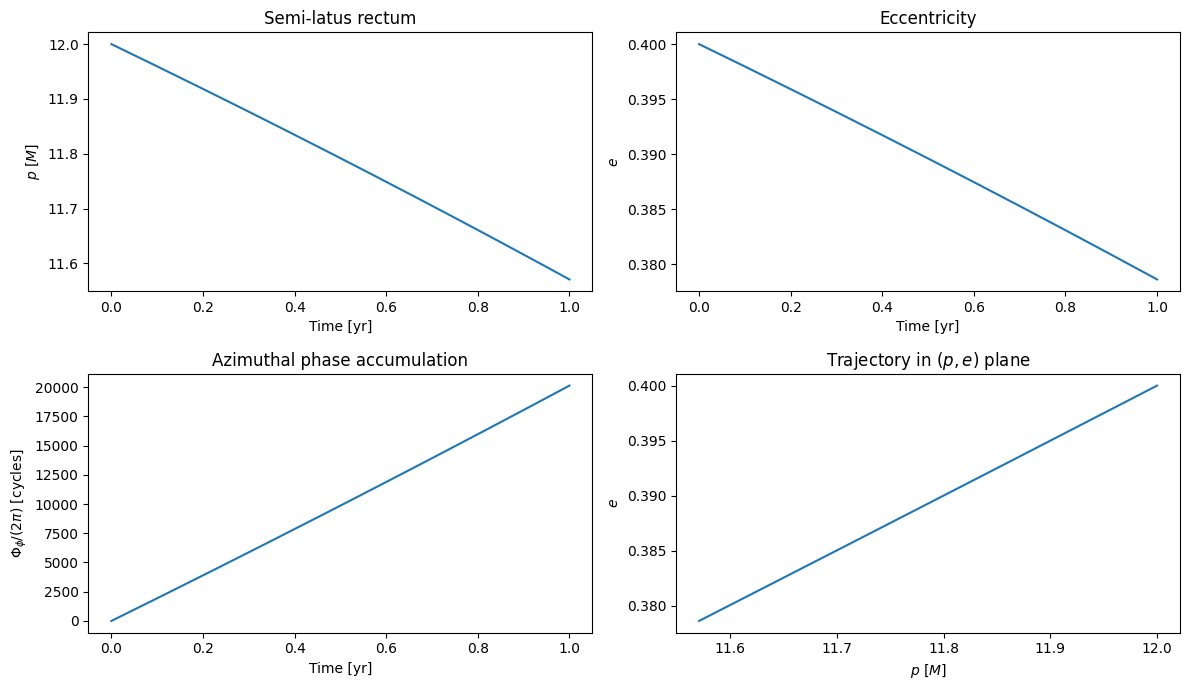

In [3]:
t_yr = np.asarray(t)[valid] / (365.25 * 24 * 3600)
p_np = np.asarray(p)[valid]
e_np = np.asarray(e)[valid]
Pphi = np.asarray(Phi_phi)[valid] / (2 * np.pi)  # in cycles
Pr   = np.asarray(Phi_r)[valid]   / (2 * np.pi)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0,0].plot(t_yr, p_np)
axes[0,0].set_xlabel("Time [yr]")
axes[0,0].set_ylabel("$p$ [$M$]")
axes[0,0].set_title("Semi-latus rectum")

axes[0,1].plot(t_yr, e_np)
axes[0,1].set_xlabel("Time [yr]")
axes[0,1].set_ylabel("$e$")
axes[0,1].set_title("Eccentricity")

axes[1,0].plot(t_yr, Pphi)
axes[1,0].set_xlabel("Time [yr]")
axes[1,0].set_ylabel("$\\Phi_\\phi / (2\\pi)$ [cycles]")
axes[1,0].set_title("Azimuthal phase accumulation")

axes[1,1].plot(p_np, e_np)
axes[1,1].set_xlabel("$p$ [$M$]")
axes[1,1].set_ylabel("$e$")
axes[1,1].set_title("Trajectory in $(p, e)$ plane")

# plt.suptitle(f"EMRI inspiral: $a=0.7$, $M=10^6\\,M_\\odot$, $\\mu=10\\,M_\\odot$, $T=1\\,{\\rm yr}$")
plt.tight_layout()
plt.show()

## 2.2  The μ/M Mass-Ratio Scaling

The FEW flux tables are normalised to $\mu = M = 1$ (geometric units).  To convert to physical units:

$$
\dot{p}_{\rm phys} = \frac{\mu}{M} \cdot \dot{p}_{\rm table}, \qquad \dot{e}_{\rm phys} = \frac{\mu}{M} \cdot \dot{e}_{\rm table}
$$

For a typical EMRI: $\mu/M = 10/10^6 = 10^{-5}$, so the inspiral rate is 100,000 times slower than the flux-table value.  The orbital phases $\Phi_\phi$, $\Phi_r$ are **not** scaled by $\mu/M$ — they accumulate at the geodesic frequencies regardless of mass ratio.

Let's check how the inspiral depth scales with the mass ratio:

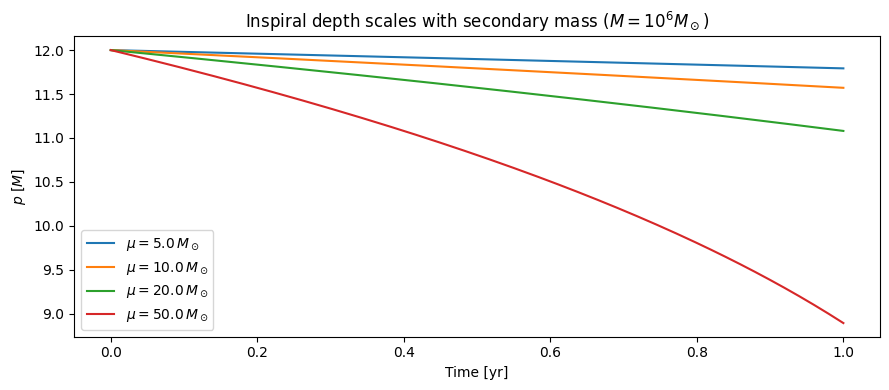

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))

for mu_val, color in zip([5.0, 10.0, 20.0, 50.0], ["C0", "C1", "C2", "C3"]):
    t_, p_, *_ = run_inspiral(
        a=0.7, p0=12.0, e0=0.4, T=1.0,
        flux_data=flux_data, M=1e6, mu=mu_val, dense_steps=150,
    )
    valid_ = ~np.isnan(np.asarray(p_))
    t_yr_ = np.asarray(t_)[valid_] / (365.25 * 24 * 3600)
    ax.plot(t_yr_, np.asarray(p_)[valid_], color=color, label=f"$\\mu = {mu_val}\\,M_\\odot$")

ax.set_xlabel("Time [yr]")
ax.set_ylabel("$p$ [$M$]")
ax.set_title("Inspiral depth scales with secondary mass ($M = 10^6 M_\\odot$)")
ax.legend()
plt.tight_layout()
plt.show()

## 2.3  Circular Orbit (e = 0)

Circular orbits are a special case.  For $e = 0$ the Jacobian $J$ is singular (both $\partial E/\partial e$ and $\partial L/\partial e$ vanish at $e = 0$ by symmetry). The ocde detects this and uses a fallback formula for circular orbits:

$$
\dot{p} = \frac{\dot{E}}{\partial E/\partial p}, \qquad \dot{e} = 0
$$

Circular orbits evolve along the circular-orbit sequence and stay circular throughout.

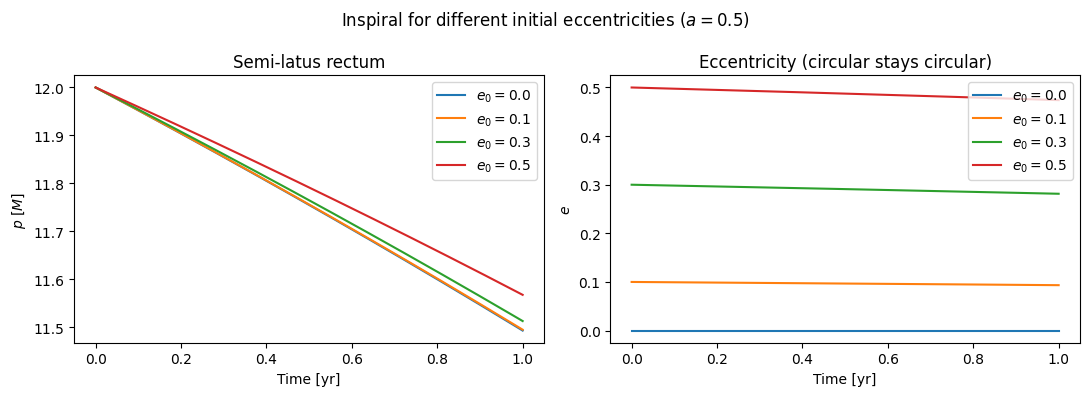

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for e0_val, color in zip([0.0, 0.1, 0.3, 0.5], ["C0", "C1", "C2", "C3"]):
    t_, p_, e_, *_ = run_inspiral(
        a=0.5, p0=12.0, e0=e0_val, T=1.0,
        flux_data=flux_data, M=1e6, mu=10.0, dense_steps=150,
    )
    valid_ = ~np.isnan(np.asarray(p_))
    t_yr_ = np.asarray(t_)[valid_] / (365.25 * 24 * 3600)
    axes[0].plot(t_yr_, np.asarray(p_)[valid_], color=color, label=f"$e_0={e0_val}$")
    axes[1].plot(t_yr_, np.asarray(e_)[valid_], color=color, label=f"$e_0={e0_val}$")

axes[0].set_xlabel("Time [yr]")
axes[0].set_ylabel("$p$ [$M$]")
axes[0].set_title("Semi-latus rectum")
axes[0].legend()

axes[1].set_xlabel("Time [yr]")
axes[1].set_ylabel("$e$")
axes[1].set_title("Eccentricity (circular stays circular)")
axes[1].legend()

plt.suptitle("Inspiral for different initial eccentricities ($a = 0.5$)")
plt.tight_layout()
plt.show()

## 2.4  Separatrix Termination

The ODE is stopped when $p < p_{\rm sep}(a, e) + \delta p_{\rm buffer}$.  This is implemented as a `diffrax.Event` with a boolean condition.  After termination, the remaining `dense_steps` entries are filled with `NaN`.  Always mask with `~np.isnan(p)` before analysis.

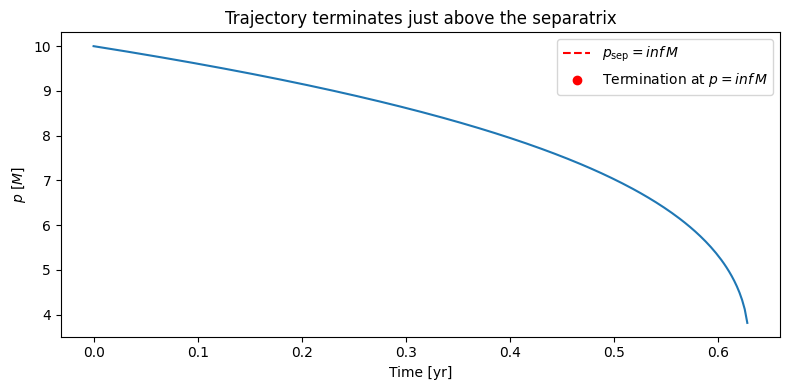

In [7]:
from fewtrax.utils.geodesic import get_separatrix

a = 0.7
t_, p_, e_, *_ = run_inspiral(
    a=a, p0=10.0, e0=0.3, T=5.0,  # 5 years, will plunge before then
    flux_data=flux_data, M=1e6, mu=50.0, dense_steps=2000,
)
valid_ = ~np.isnan(np.asarray(p_))
p_fin  = float(p_[valid_][-1])
e_fin  = float(e_[valid_][-1])
p_sep  = float(get_separatrix(a, e_fin, 1.0))

t_yr_ = np.asarray(t_)[valid_] / (365.25 * 24 * 3600)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_yr_, np.asarray(p_)[valid_])
ax.axhline(p_sep, color="r", linestyle="--", label=f"$p_{{\\rm sep}} = {p_sep:.3f}\\,M$")
ax.scatter([t_yr_[-1]], [p_fin], color="r", zorder=5, label=f"Termination at $p={p_fin:.3f}\\,M$")
ax.set_xlabel("Time [yr]")
ax.set_ylabel("$p$ [$M$]")
ax.set_title("Trajectory terminates just above the separatrix")
ax.legend()
plt.tight_layout()
plt.show()

## 2.5  JIT Timing

The ODE solve is wrapped in `@eqx.filter_jit`.  The first call traces and compiles; subsequent calls reuse the compiled kernel.

In [8]:
import time

traj = EMRIInspiral(flux_data)

call_kwargs = dict(p0=12.0, e0=0.4, a=0.7, T=1.0, M=1e6, mu=10.0, dense_steps=100)

# First call: compilation
t0 = time.perf_counter()
_ = traj(**call_kwargs)
t1 = time.perf_counter()
print(f"First call  (compile): {1000*(t1-t0):.0f} ms")

# Second and third calls: cached
for i in range(3):
    t0 = time.perf_counter()
    _ = traj(**call_kwargs)
    t1 = time.perf_counter()
    print(f"Call {i+2} (cached):     {1000*(t1-t0):.1f} ms")

First call  (compile): 749 ms
Call 2 (cached):     1.6 ms
Call 3 (cached):     1.2 ms
Call 4 (cached):     1.2 ms


## 2.6  vmap Over Initial Conditions

One of JAX's main advantages: `jax.vmap` vectorises a function over a batch of inputs with no Python loop overhead.  Here we compute trajectories for a grid of $(p_0, e_0)$ values simultaneously.

In [19]:
traj = EMRIInspiral(flux_data)

# Batch of 8 starting points
N_start = 100
p0_batch = jnp.linspace(6.0, 10.0, N_start, dtype=jnp.float64)
e0_batch = jnp.full(N_start, 0.3, dtype=jnp.float64)

def single_traj(p0, e0):
    _, p, *_ = traj(p0=p0, e0=e0, a=0.99, T=2.0, M=1e6, mu=10.0, dense_steps=200)
    return p

# vmap over the first two arguments
batch_traj = jax.vmap(single_traj)

t0 = time.perf_counter()
p_batch = batch_traj(p0_batch, e0_batch)
t1 = time.perf_counter()
print(f"Batch of {len(p0_batch)} trajectories in {1000*(t1-t0):.1f} ms")
print(f"Output shape: {p_batch.shape}  (N_batch × N_steps)")

Batch of 100 trajectories in 207.2 ms
Output shape: (100, 200)  (N_batch × N_steps)


In [20]:
batch_traj = jax.vmap(single_traj)

In [21]:
%%timeit
p_batch = batch_traj(p0_batch, e0_batch)

98 ms ± 697 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


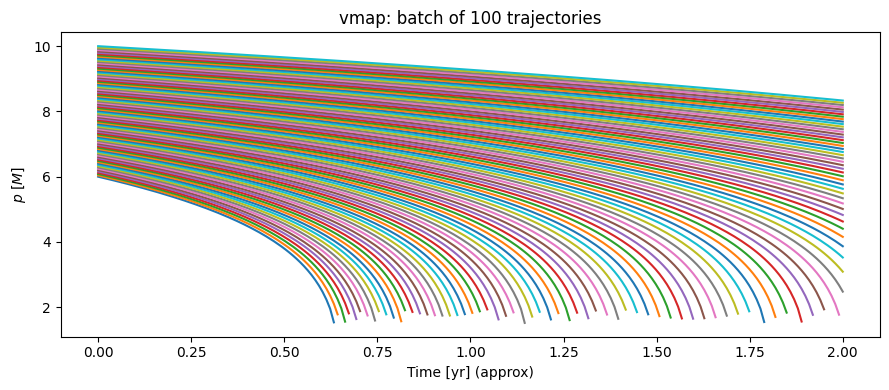

In [23]:
fig, ax = plt.subplots(figsize=(9, 4))
t_dummy = np.linspace(0, 2.0, 200)  # approximate time axis
for i in range(len(p0_batch)):
    p_i = np.asarray(p_batch[i])
    valid_ = ~np.isnan(p_i)
    ax.plot(t_dummy[valid_], p_i[valid_], label=f"$p_0={float(p0_batch[i]):.1f}$")
ax.set_xlabel("Time [yr] (approx)")
ax.set_ylabel("$p$ [$M$]")
ax.set_title("vmap: batch of 100 trajectories")
# ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## Summary

The `EMRIInspiral` module:

1. Evaluates the PN-normalised fluxes from the FEW tables via JAX cubic splines
2. Converts $(\dot{E}, \dot{L})$ → $(\dot{p}, \dot{e})$ via `jax.jacfwd`-computed Jacobian inversion
3. Integrates the 5-component ODE $(p, e, \Phi_\phi, \Phi_\theta, \Phi_r)$ with `diffrax.Tsit5`
4. Stops at the separatrix via `diffrax.Event`
5. Scales $\dot{p}, \dot{e}$ by $\mu/M$ via the diffrax `args` mechanism

**Next:** [03_amplitude_interpolation.ipynb](03_amplitude_interpolation.ipynb) — evaluating Teukolsky mode amplitudes along the trajectory.